# Работа по теме "Методы классификации"

## Описание

Работа предполагает самостоятельное исследование данных и построение классификационных моделей.

Основная задача работы - научиться работать с методами классификации, настраивать и отбирать лучшие модели.

Предлагается два набора данных. Первый предлагается для отработки изученных моделей, метрик и методов работы с данными. Второй набор предлагается для возможности отработки методов работы с текстовыми данными.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- рассмотрено не менее трех различных методов классификации;
- создаваемые модели натроены для получения наилучших результатов;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы;
- верно использованы различные подходы к обработке текста.

В результате необходимо получить наилучшую модель классификации для числовых данных, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс выбора и настройки моделей. Для текстовых данных необходимо получить результат, показав процесс обработки текста.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [2]:
def metrics(y_true, y_pred, title='Матрица ошибок'):
    print(classification_report(y_true, y_pred, target_names=['Phase 1 (RGB)', 'Phase 2 (RC)']))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Pred: 1', 'Pred: 2'],
                yticklabels=['Actual: 1', 'Actual: 2'])
    plt.title(title)
    plt.xlabel('Предсказание')
    plt.ylabel('Факт')
    plt.show()

# Аэросейсмология

Набор данных `Data_classified_phase.csv`.

В наборе представлены данные по звездам с указанием их эволюционных фаз. Описание столбцов можно увидеть [тут](https://www.kaggle.com/datasets/fernandolima23/asteroseismology-of-16000-kepler-red-giants)

Требуется построить классификационную модель.

In [3]:
df = pd.read_csv('Data_classified_phase.csv')
df.head()

,Kpmag,numax,e_numax,Delnu,e_Delnu,A,e_A,Width,e_Width,Teff,...,e_NoCorR,RGBcorM,e_RGBcorM,RGBcorR,e_RGBcorR,ClcorM,e_ClcorM,ClcorR,e_ClcorR,Phase
0,9.20,29.99,0.60,3.399,0.011,104.9,4.6,12.3,1.5,4751,...,0.41,1.55,0.13,13.26,0.39,1.72,0.14,13.97,0.41,1
1,13.23,29.48,0.48,3.962,0.116,149.7,8.3,12.0,3.9,5188,...,0.68,1.04,0.15,10.74,0.70,1.00,0.14,10.52,0.68,2
2,12.58,41.39,0.54,4.311,0.013,86.1,4.6,15.3,1.6,4728,...,0.26,1.54,0.09,11.29,0.24,1.72,0.10,11.92,0.26,1
3,12.14,41.17,0.90,4.414,0.061,63.8,2.9,24.8,2.7,5072,...,0.48,1.67,0.17,11.55,0.48,1.75,0.18,11.83,0.49,2
4,11.74,36.91,0.71,3.991,0.064,116.1,9.6,14.0,2.4,4718,...,0.53,1.50,0.16,11.80,0.50,1.67,0.17,12.43,0.53,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15388 entries, 0 to 15387
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Kpmag      15388 non-null  float64
 1   numax      15388 non-null  float64
 2   e_numax    15388 non-null  float64
 3   Delnu      15388 non-null  float64
 4   e_Delnu    15388 non-null  float64
 5   A          15388 non-null  object 
 6   e_A        15388 non-null  object 
 7   Width      15388 non-null  object 
 8   e_Width    15388 non-null  object 
 9   Teff       15388 non-null  int64  
 10  e_Teff     15388 non-null  int64  
 11  log(g)     15388 non-null  float64
 12  e_log(g)   15388 non-null  float64
 13  [Fe/H]     15388 non-null  float64
 14  e_[Fe/H]   15388 non-null  float64
 15  NoCorM     15388 non-null  float64
 16  e_NoCorM   15388 non-null  float64
 17  NoCorR     15388 non-null  float64
 18  e_NoCorR   15388 non-null  float64
 19  RGBcorM    15388 non-null  float64
 20  e_RGBc

In [6]:
df = df.apply(pd.to_numeric, errors='coerce')

In [7]:
df.describe()

,Kpmag,numax,e_numax,Delnu,e_Delnu,A,e_A,Width,e_Width,Teff,...,e_NoCorR,RGBcorM,e_RGBcorM,RGBcorR,e_RGBcorR,ClcorM,e_ClcorM,ClcorR,e_ClcorR,Phase
count,15388.000000,15388.000000,15388.000000,15388.00000,15388.000000,14851.000000,14851.000000,14851.000000,14851.000000,15388.00000,...,15388.000000,15388.000000,15388.000000,15388.000000,15388.00000,15388.000000,15388.000000,15388.000000,15388.000000,15388.000000
mean,12.632402,64.673195,0.903276,6.16765,0.047327,95.059174,5.328045,20.241620,2.009454,4903.08994,...,0.407304,1.344886,0.126670,9.720831,0.39403,1.422839,0.134646,10.024309,0.409406,1.500585
std,1.211778,50.958690,0.891080,3.56072,0.069763,51.897428,5.110774,11.734342,2.181685,212.91843,...,0.452677,0.409900,0.106109,3.053634,0.42836,0.417293,0.114116,3.216817,0.453516,0.500016
min,6.240000,3.970000,0.040000,0.74700,0.008000,10.700000,0.700000,1.800000,0.200000,3225.00000,...,0.060000,0.340000,0.030000,3.240000,0.06000,0.430000,0.040000,3.470000,0.060000,1.000000
25%,11.900000,31.680000,0.560000,3.97675,0.017000,59.900000,2.800000,13.000000,1.100000,4769.00000,...,0.180000,1.100000,0.080000,7.880000,0.17000,1.170000,0.090000,8.160000,0.180000,1.000000
50%,12.850000,42.260000,0.720000,4.54050,0.028000,90.800000,4.400000,15.600000,1.400000,4907.00000,...,0.310000,1.270000,0.100000,10.220000,0.30000,1.350000,0.110000,10.520000,0.310000,2.000000
75%,13.510000,79.522500,1.000000,7.27000,0.050000,120.900000,6.000000,23.700000,2.000000,5047.00000,...,0.460000,1.480000,0.130000,11.160000,0.45000,1.580000,0.140000,11.450000,0.460000,2.000000
max,16.850000,273.160000,70.270000,19.29400,1.338000,745.200000,82.800000,101.200000,46.900000,6356.00000,...,9.800000,5.150000,2.800000,48.610000,9.00000,5.240000,2.950000,51.190000,9.800000,2.000000


In [9]:
nan_counts = df.isnull().sum()
print(nan_counts[nan_counts > 0])
print(f'Всего строк: {len(df)}')
print(f'Строк с пропусками: {df.isnull().any(axis=1).sum()}')

A          537
e_A        537
Width      537
e_Width    537
dtype: int64
Всего строк: 15388
Строк с пропусками: 537


In [10]:
df = df.dropna()
df.shape

(14851, 28)

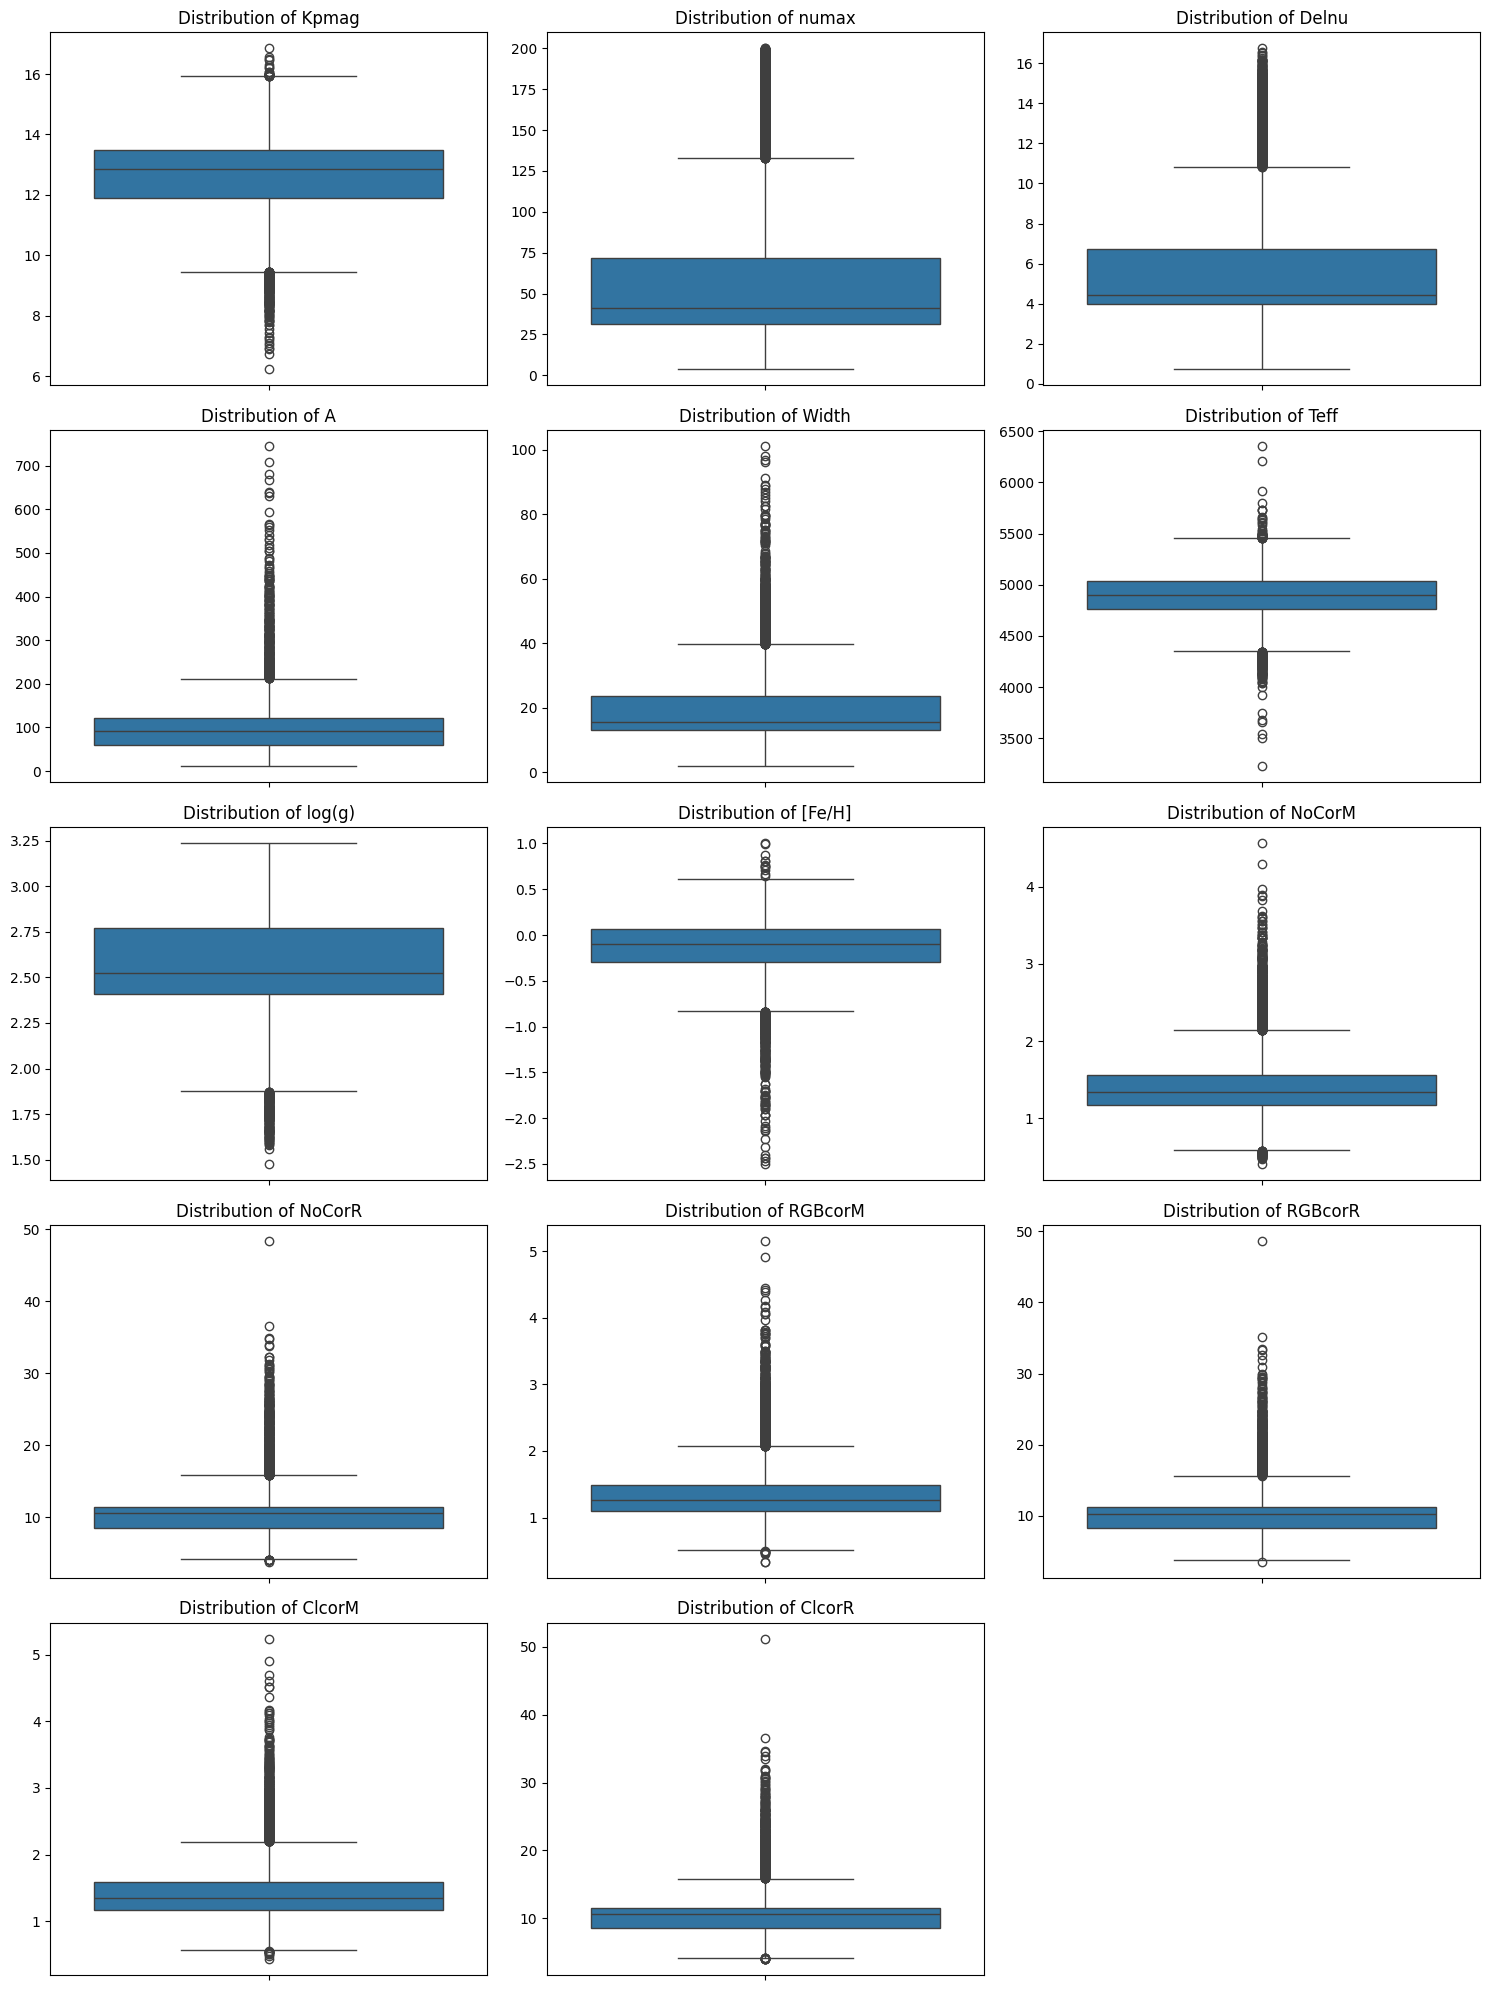

In [12]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
features_to_plot = [col for col in numerical_cols if not col.startswith('e_') and col != 'Phase']

n_features = len(features_to_plot)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
for i, col in enumerate(features_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Distribution of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

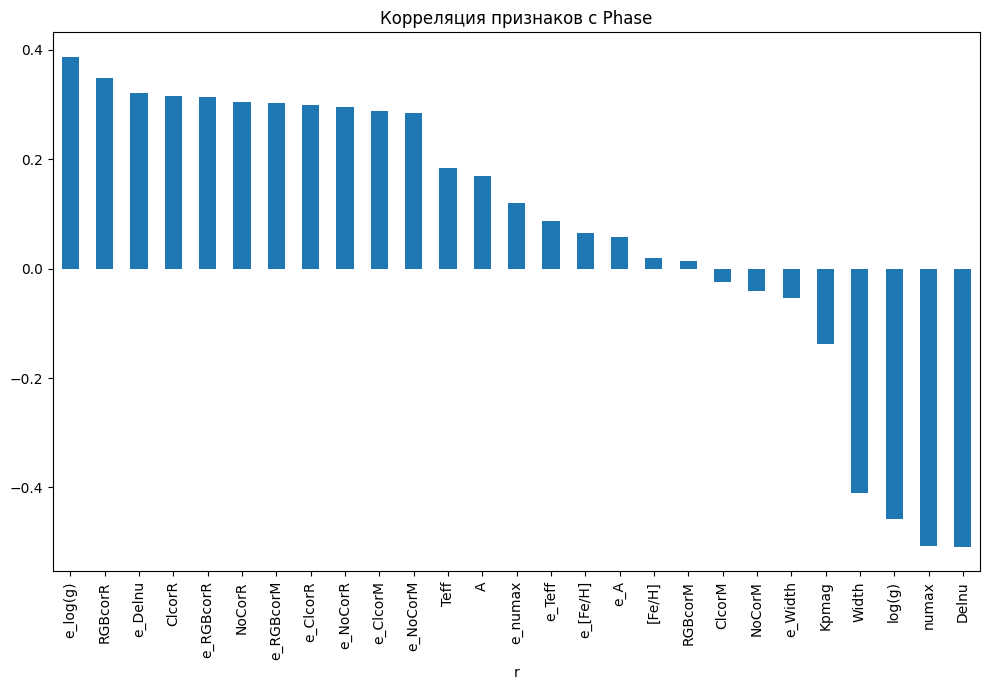

,Phase
e_log(g),0.387203
RGBcorR,0.348708
e_Delnu,0.320702
ClcorR,0.315257
e_RGBcorR,0.312857
NoCorR,0.304154
e_RGBcorM,0.303631
e_ClcorR,0.299135
e_NoCorR,0.294627
e_ClcorM,0.288437


In [15]:
corr_target = df.corr()['Phase'].drop('Phase').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
corr_target.plot(kind='bar')
plt.title('Корреляция признаков с Phase')
plt.xlabel('r')
plt.tight_layout()
plt.show()

corr_target

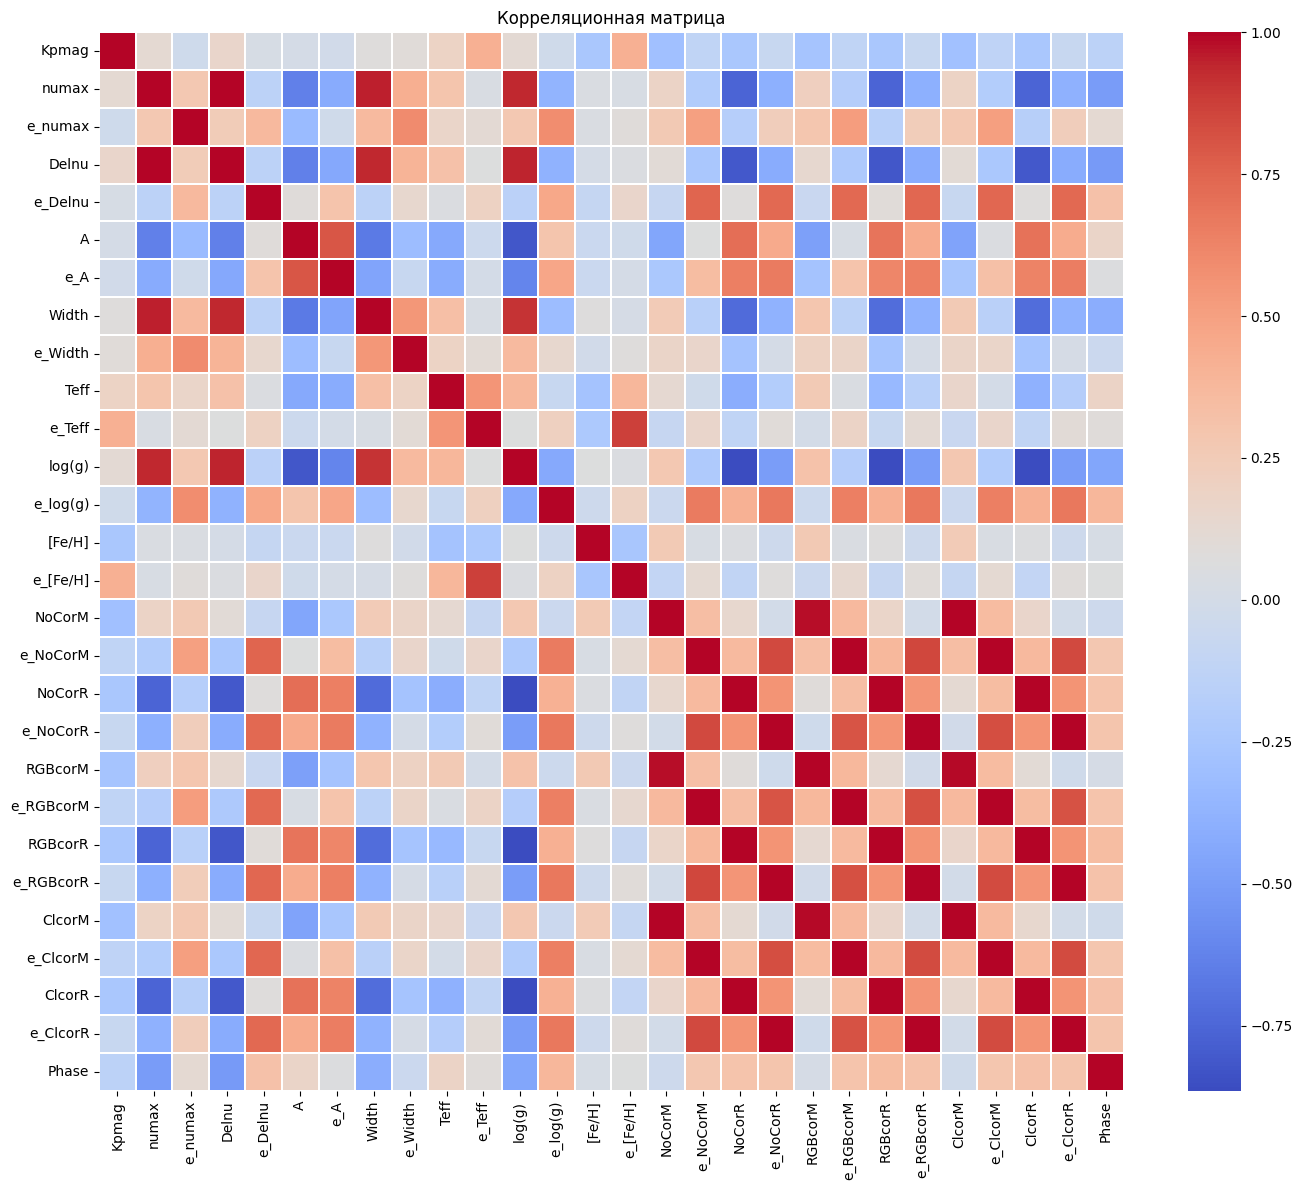

In [16]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.1)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

In [17]:
drop_cols = ['RGBcorM', 'ClcorM', 'e_RGBcorM', 'e_ClcorM',
             'RGBcorR', 'ClcorR', 'e_RGBcorR', 'e_ClcorR',
             'numax']

df_model = df.drop(columns=drop_cols)
display(f'Признаков до отбора: {df.shape[1] - 1}')
display(f'Признаков после отбора: {df_model.shape[1] - 1}')
display('Оставшиеся признаки:')
[c for c in df_model.columns if c != 'Phase']

'Признаков до отбора: 27'

'Признаков после отбора: 18'

'Оставшиеся признаки:'

['Kpmag',
 'e_numax',
 'Delnu',
 'e_Delnu',
 'A',
 'e_A',
 'Width',
 'e_Width',
 'Teff',
 'e_Teff',
 'log(g)',
 'e_log(g)',
 '[Fe/H]',
 'e_[Fe/H]',
 'NoCorM',
 'e_NoCorM',
 'NoCorR',
 'e_NoCorR']

In [18]:
X = df_model.drop('Phase', axis=1)
y = df_model['Phase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

display(f'Обучающая выборка: {X_train.shape}')
display(f'Тестовая выборка:  {X_test.shape}')
display(f'Распределение классов в train:')
display(y_train.value_counts())
display(f'Распределение классов в test:')
display(y_test.value_counts())

'Обучающая выборка: (11880, 18)'

'Тестовая выборка:  (2971, 18)'

'Распределение классов в train:'

,count
Phase,
2,6162
1,5718


'Распределение классов в test:'

,count
Phase,
2,1541
1,1430


In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## Модель kNN

Лучшее значение k: 10

Оценка модели kNN (на тестовых данных):
               precision    recall  f1-score   support

Phase 1 (RGB)       0.94      0.94      0.94      1430
 Phase 2 (RC)       0.95      0.94      0.94      1541

     accuracy                           0.94      2971
    macro avg       0.94      0.94      0.94      2971
 weighted avg       0.94      0.94      0.94      2971



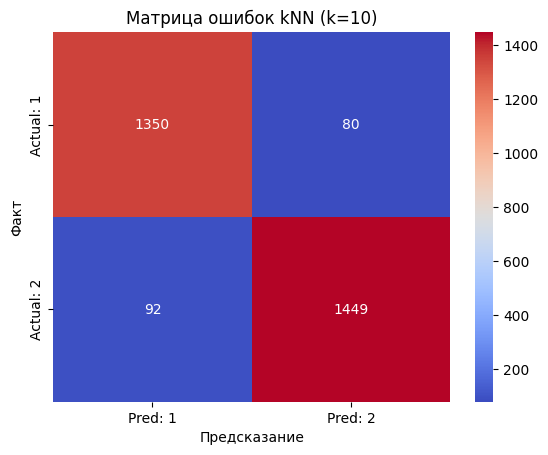

In [20]:
param_grid = {'n_neighbors': np.arange(1, 21)}
knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_sc, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f'Лучшее значение k: {best_k}')

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)

y_pred_knn = knn_best.predict(X_test_sc)

print('\nОценка модели kNN (на тестовых данных):')
metrics(y_test, y_pred_knn, title=f'Матрица ошибок kNN (k={best_k})')

## Модель логистической регрессии


Оценка модели логистической регрессии (на тестовых данных):
               precision    recall  f1-score   support

Phase 1 (RGB)       0.95      0.93      0.94      1430
 Phase 2 (RC)       0.93      0.95      0.94      1541

     accuracy                           0.94      2971
    macro avg       0.94      0.94      0.94      2971
 weighted avg       0.94      0.94      0.94      2971



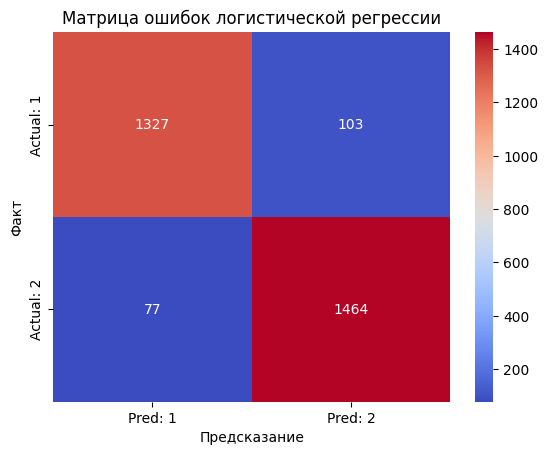

In [21]:
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train_sc, y_train)

y_pred_lr = log_reg.predict(X_test_sc)

print('\nОценка модели логистической регрессии (на тестовых данных):')
metrics(y_test, y_pred_lr, title='Матрица ошибок логистической регрессии')

## Модель RandomForest

Лучшие параметры для RandomForest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}

Оценка модели RandomForest (на тестовых данных):
               precision    recall  f1-score   support

Phase 1 (RGB)       0.96      0.96      0.96      1430
 Phase 2 (RC)       0.97      0.96      0.96      1541

     accuracy                           0.96      2971
    macro avg       0.96      0.96      0.96      2971
 weighted avg       0.96      0.96      0.96      2971



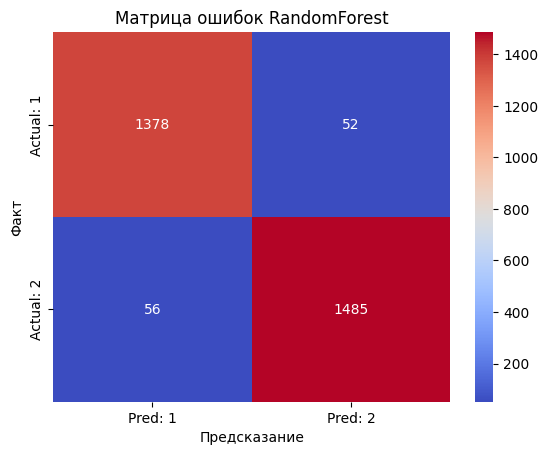

In [22]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_classifier = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(rf_classifier, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train_sc, y_train)

best_params_rf = grid_search_rf.best_params_
print(f'Лучшие параметры для RandomForest: {best_params_rf}')

rf_best = RandomForestClassifier(**best_params_rf, random_state=42)
rf_best.fit(X_train_sc, y_train)

y_pred_rf = rf_best.predict(X_test_sc)

print('\nОценка модели RandomForest (на тестовых данных):')
metrics(y_test, y_pred_rf, title='Матрица ошибок RandomForest')

### Выводы по моделям:

1.  **k-Nearest Neighbors (kNN)**:
    *   Лучшее `k`: 10
    *   **Accuracy: 0.94**
    *   Precision: 0.94
    *   Recall: 0.94
    *   F1-score: 0.94

2.  **Логистическая регрессия (Logistic Regression)**:
    *   **Accuracy: 0.94**
    *   Precision: 0.94
    *   Recall: 0.94
    *   F1-score: 0.94

3.  **Случайный лес (RandomForest)**:
    *   Лучшие параметры: `{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}`
    *   **Accuracy: 0.96**
    *   Precision: 0.96
    *   Recall: 0.96
    *   F1-score: 0.96

**Какая модель лучше?**

На основании метрик `accuracy`, `precision`, `recall` и `f1-score` на тестовой выборке, модель RandomForest показала наилучшие результаты с точностью 0.96, опережая kNN и Логистическую регрессию, которые обе достигли точности 0.94. Это означает, что Random Forest лучше всего справляется с классификацией эволюционных фаз звезд на данном наборе данных.